# Entrenamiento Interactivo y Configurable - Unet++ (Segmentación de DFU)

Este notebook permite configurar los parámetros de entrenamiento de la red neural de forma interactiva y ejecutar el entrenamiento completo reutilizando el código optimizado de los scripts de entrenamiento del repositorio.

### 1. Configurar Entorno y Añadir Rutas

In [1]:
import os
import sys
import torch
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Encontrar la raíz del repositorio
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), "../.."))
print(f"Raíz del Repositorio: {REPO_ROOT}")

# Definir la ruta del modelo y añadirla al path para importar módulos locales
MODEL_DIR = os.path.join(REPO_ROOT, "src", "SegmentationNetworks", "Models", "Unet++")
sys.path.append(MODEL_DIR)
print(f"Ruta del Modelo: {MODEL_DIR}")

Raíz del Repositorio: /home/diego-villalba/Proyecto_DFU
Ruta del Modelo: /home/diego-villalba/Proyecto_DFU/src/SegmentationNetworks/Models/Unet++


/home/diego-villalba/Proyecto_DFU/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/diego-villalba/Proyecto_DFU/.venv/lib/python3.12/site-packages/albumentations/__init__.py:13: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.17). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


### 2. Importar Script de Entrenamiento
Importamos el script `train.py` del modelo, que contiene la lógica científica encapsulada.

In [2]:
import train
print("Script de entrenamiento importado con éxito.")

torch.Size([3, 1, 160, 160])


Device:  cuda is available 
 ----------------------
Script de entrenamiento importado con éxito.


### 3. Cargar Datos e Inspeccionar el Tamaño del Dataset
Inicializamos los cargadores de datos usando las transformaciones estándar y mostramos el número exacto de imágenes disponibles para entrenamiento y validación.

In [3]:
TRAIN_IMG_DIR = os.path.join(REPO_ROOT, "data", "miccai", "train_images")
TRAIN_MASK_DIR = os.path.join(REPO_ROOT, "data", "miccai", "train_masks")
VAL_IMG_DIR = os.path.join(REPO_ROOT, "data", "miccai", "val_images")
VAL_MASK_DIR = os.path.join(REPO_ROOT, "data", "miccai", "val_masks")

# Definir transformaciones estándar
train_transform = A.Compose([
    A.Resize(height=240, width=240),
    A.Rotate(limit=35, p=0.5),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.1),
    A.Normalize(mean=[0.0, 0.0, 0.0], std=[1.0, 1.0, 1.0], max_pixel_value=255.0),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(height=240, width=240),
    A.Normalize(mean=[0.0, 0.0, 0.0], std=[1.0, 1.0, 1.0], max_pixel_value=255.0),
    ToTensorV2()
])

# Cargar loaders
train_loader, val_loader = train.get_loaders(
    TRAIN_IMG_DIR, TRAIN_MASK_DIR,
    VAL_IMG_DIR, VAL_MASK_DIR,
    batch_size=4,
    train_transform=train_transform,
    val_transform=val_transform,
    num_workers=0,
    pin_memory=True
)

print("=" * 50)
print(f"Número de imágenes de ENTRENAMIENTO: {len(train_loader.dataset)}")
print(f"Número de imágenes de VALIDACIÓN: {len(val_loader.dataset)}")
print("=" * 50)

Número de imágenes de ENTRENAMIENTO: 858
Número de imágenes de VALIDACIÓN: 152


### 4. Configurar Parámetros del Entrenamiento
Puedes modificar libremente las variables globales expuestas a continuación antes de lanzar el entrenamiento para ajustar los hiperparámetros.

In [4]:
# Modificar los hiperparámetros expuestos en el script train
train.NUM_EPOCHS = 40  # Modificado programáticamente
train.LEARNING_RATE = 9.88e-4  # Modificado programáticamente
train.BATCH_SIZE = 16  # Modificado programáticamente
train.DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Configuración cargada:")
print(f"- Épocas: {train.NUM_EPOCHS}")
print(f"- Learning Rate: {train.LEARNING_RATE}")
print(f"- Batch Size: {train.BATCH_SIZE}")
print(f"- Dispositivo: {train.DEVICE}")

Configuración cargada:
- Épocas: 40
- Learning Rate: 0.000988
- Batch Size: 16
- Dispositivo: cuda


### 5. Lanzar Entrenamiento Completo
Ejecutamos el ciclo completo de entrenamiento y validación llamando a la función `main()` importada de `train.py`. El proceso imprimirá la pérdida por época (loss per epoch) y las métricas complementarias en tiempo real y guardará el checkpoint correspondiente.

Iniciando entrenamiento del modelo...
Epoch: 1


  0%|          | 0/54 [00:00<?, ?it/s]

  0%|          | 0/54 [00:00<?, ?it/s, loss=<built-in method item of Tensor object at 0x7ca0ed0610e0>]

  2%|▏         | 1/54 [00:00<00:31,  1.67it/s, loss=<built-in method item of Tensor object at 0x7ca0ed0610e0>]

  2%|▏         | 1/54 [00:00<00:31,  1.67it/s, loss=<built-in method item of Tensor object at 0x7ca0ed065cc0>]

...

 98%|█████████▊| 53/54 [00:16<00:00,  3.13it/s, loss=<built-in method item of Tensor object at 0x7ca0ed0c11d0>]

100%|██████████| 54/54 [00:16<00:00,  3.55it/s, loss=<built-in method item of Tensor object at 0x7ca0ed0c11d0>]

100%|██████████| 54/54 [00:16<00:00,  3.20it/s, loss=<built-in method item of Tensor object at 0x7ca0ed0c11d0>]

Acc: 99.493
Dice score: 0.806291401386261


Saving metrics...
Gráfica de Loss y Dice guardada en: output_assets_model/dice_loss_graph_UnetPlusPlus.png
Metrics saved successfully!
¡Entrenamiento finalizado con éxito!


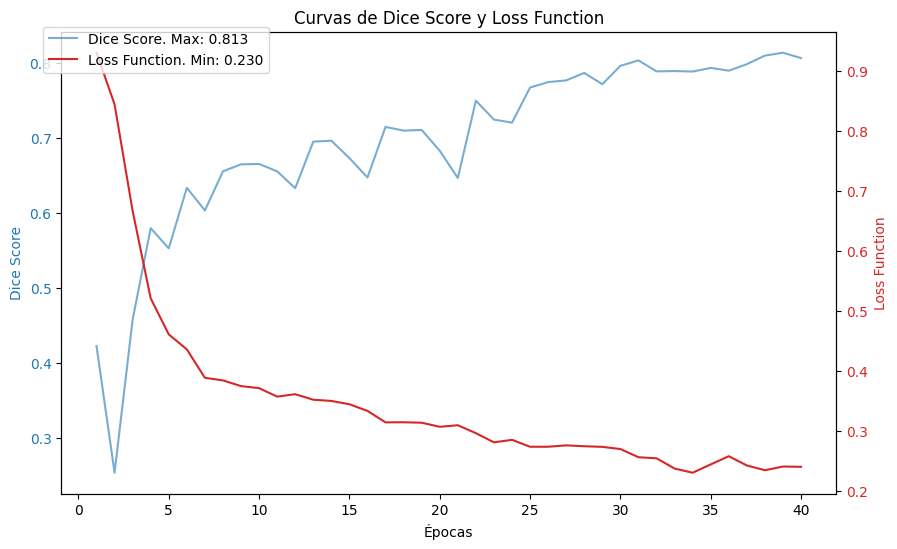

In [5]:
# Lanzamos el bucle principal
print("Iniciando entrenamiento del modelo...")
model_trained = train.main(NUM_EPOCHS=train.NUM_EPOCHS)
print("¡Entrenamiento finalizado con éxito!")